## Setup and imports

Import **pandas**, **NumPy**, **matplotlib**, **seaborn**, **scikit-learn**, **PyTorch**, and **NetworkX** for loading the saved graph, merging prediction tables, training a simple calibrator, and plotting. `pd.set_option('future.no_silent_downcasting', True)` avoids silent dtype coercion in newer pandas.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sbn
from sklearn.metrics import roc_auc_score
import torch 
import networkx as nx
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lincs_gsnn.utils.eval import filtered_rank
from lincs_gsnn.utils.eval import eval_edge_inference

pd.set_option('future.no_silent_downcasting', True)

%load_ext autoreload
%autoreload 2

# set random seed 
np.random.seed(42)

/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paths to saved artifacts

`root_dir` points at the training/inference run directory. `bionetwork/` holds the graph checkpoint and removed test edges; `infer_edges/` holds per-sample or aggregated edge-inference outputs. Adjust `root_dir` if you move the run.

In [2]:
root_dir = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/default/' 

net_dir = f'{root_dir}/bionetwork/'
out_dir = f'{root_dir}/infer_edges/'

## Load the training (function–function) edges

Load `bionetwork.pt` (heterogeneous graph bundle). The **function → function** edges are the supervised structure used during training. We name endpoints and build `train_edges` so later steps can label which predicted edges overlap training.

In [3]:
data = torch.load(net_dir + 'bionetwork.pt', weights_only=False)

src,dst = data.edge_index_dict['function', 'to', 'function']
src_names = np.array(data.node_names_dict['function'])[src]
dst_names = np.array(data.node_names_dict['function'])[dst]

train_edges = pd.DataFrame({'source': src_names, 'target': dst_names, 'train_edge': True})
print('# train edges: ', len(train_edges))
train_edges.head()


# train edges:  7817


,source,target,train_edge
0,RNA__NOTCH1,PROTEIN__NOTCH1,True
1,PROTEIN__EGFR,PROTEIN__JAK1,True
2,PROTEIN__EGFR,PROTEIN__STAT3,True
3,PROTEIN__EGFR,PROTEIN__SHC1,True
4,PROTEIN__EGFR,PROTEIN__PTPN11,True


## Load held-out test edges

Read `removed_edges.csv` (edges held out from training). Rename to `source`/`target` and mark `test_edge=True`. These are the positive edges you care about for ranking and AUROC.

In [4]:
test_edges = pd.read_csv(net_dir + 'removed_edges.csv')
test_edges = test_edges[['src_name', 'dst_name']].rename(columns={'src_name': 'source', 'dst_name': 'target'})
test_edges = test_edges.assign(test_edge=True)
print('# test edges: ', len(test_edges))
test_edges.head()

# test edges:  414


,source,target,test_edge
0,PROTEIN__GATA3,RNA__MBNL2,True
1,PROTEIN__FOS,RNA__MBNL2,True
2,PROTEIN__CEBPA,RNA__CDK2,True
3,PROTEIN__E2F4,RNA__CDK2,True
4,PROTEIN__RELA,RNA__CDK4,True


## Load aggregated inferred edge scores

Either **recompute** the mean over 50 Monte Carlo samples from `sample_*/inferred_output_edges_test.csv` (slow; the `if False` branch) or **read** the precomputed average `000___avg_inferred_edge_results.csv` (fast; `else`). The branch keeps the notebook runnable without re-scanning 50 files every time.

In [5]:
if False: 
    res = pd.read_csv(out_dir + f'sample_0/inferred_output_edges_test.csv', low_memory=False)
    for i in range(1,50):
        print(f'sample_{i}', end='\r')
        tmp = pd.read_csv(out_dir + f'sample_{i}/inferred_output_edges_test.csv', low_memory=False)
        res = pd.concat([res, tmp], axis=0, ignore_index=True)
        res = res.groupby(['func_node', 'output_node']).agg({'snr': 'sum', 
                                                        'r2_gain': 'sum', 
                                                        'r_gain': 'sum', 
                                                        'r': 'sum', 
                                                        'r2': 'sum', 
                                                        'model_r2': 'sum', 
                                                        'model_r': 'sum', 
                                                        'l2_norm': 'sum'}).reset_index()

    res[['snr', 'r2_gain', 'r_gain', 'r', 'r2', 'model_r2', 'model_r', 'l2_norm']] = res[['snr', 'r2_gain', 'r_gain', 'r', 'r2', 'model_r2', 'model_r', 'l2_norm']].values / 50

    res = res.assign(output_func = ['RNA__' + x.split('__')[1] for x in res.output_node.values])
    res.to_csv(out_dir + '000___avg_inferred_edge_results.csv', index=False)

else: 
    res = pd.read_csv(out_dir + '000___avg_inferred_edge_results.csv', low_memory=False)


## Merge predictions with train/test labels

Concatenate train and test metadata and **left-merge** onto inference rows on `(func_node, output_func)`. Rename to `source`/`target`, fill missing flags as false, drop self-loops (`source == target`), and add simple `prot_edge` / `rna_edge` / `mir_edge` flags. The assert checks an edge is never both train and test.

In [6]:
edge_meta = pd.concat([train_edges, test_edges], axis=0).reset_index(drop=True)

res = res.merge(edge_meta, left_on=['func_node', 'output_func'], right_on=['source', 'target'], how='left')
res = res[['func_node', 'output_func', 'train_edge', 'test_edge', 'snr' ,'r2_gain', 'r_gain', 'r2', 'r', 'model_r', 'model_r2', 'l2_norm']]
res = res.rename(columns={'func_node': 'source', 'output_func': 'target'})
res = res.fillna({'train_edge': False, 'test_edge': False})

# remove all edges from RNA__xxx --> RNA__xxx (GENE__xxx)
# essentially self edges and shouldn't be considered candidate edges 
res = res[lambda x: x.source != x.target]

res = res.assign(prot_edge = lambda x: x.source.str.contains('PROTEIN__'))
res = res.assign(rna_edge = lambda x: x.source.str.contains('RNA__'))
res = res.assign(mir_edge = lambda x: x.source.str.contains('mir__'))

assert (res.train_edge & res.test_edge).any() == False, 'some edges are both train and test'

print('# edges: ', len(res))

# edges:  1688028


## Visual check: observed vs model correlation

Scatter **Pearson `r`** vs **`model_r`** for test positives (black) and negatives (red, downweighted). Quick sanity check that the model tracks the data on held-out and random edges.

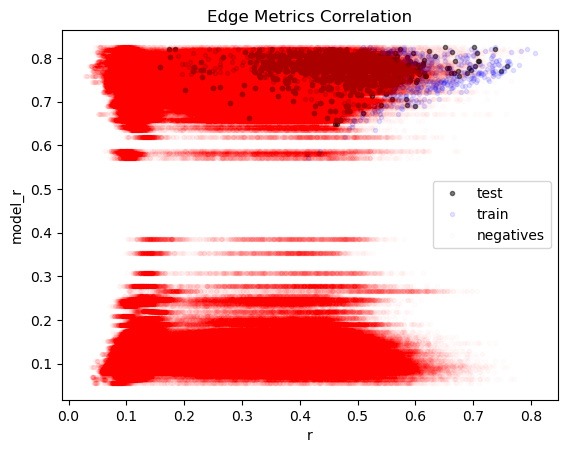

In [7]:
x1 = 'r'
x2 = 'model_r'
plt.figure() 
plt.plot(res[lambda x: x.test_edge][x1], res[lambda x: x.test_edge][x2], 'k.', alpha=0.5, label='test')
plt.plot(res[lambda x: x.train_edge][x1], res[lambda x: x.train_edge][x2], 'b.', alpha=0.1, label='train')
plt.plot(res[lambda x: ~(x.train_edge | x.test_edge)][x1], res[lambda x: ~(x.train_edge | x.test_edge)][x2], 'r.', alpha=0.01, label='negatives')
plt.legend()
plt.xlabel(x1)
plt.ylabel(x2)
plt.title('Edge Metrics Correlation')

plt.savefig(f'{root_dir}/OEI_r_vs_model_r_correlation.png', dpi=300)
plt.show()

## Calibrated score: logistic regression on features

Fit a **logistic regression** on **non-test** edges (train positives vs negatives) using `r`, `r2`, `model_r`, `model_r2`, `l2_norm`. Class weighting balances positives/negatives. **Note:** `auroc_clf` is computed on the **same** rows used to fit the model, so it is an in-sample (optimistic) score—not a held-out validation. The pipeline is then applied to **all** rows to produce `prob` for downstream metrics.

> NOTE: filtering test edges in this training step is a form of data leak. Therefore, we need to include test edges as "negatives". 

In [8]:
features = ['r', 'model_r', 'r2', 'model_r2', 'l2_norm']

X = res[features].values
y = (res.train_edge.values == True).astype(int)

print(X.shape, y.shape)

clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight='balanced', max_iter=10000)),
    ]
)
clf.fit(X, y)
yhat = clf.predict_proba(X)[:, 1]
auroc_clf = roc_auc_score(y, yhat)
print(f'auroc_clf (train only): {auroc_clf}')

res = res.assign(prob = clf.predict_proba(res[features].values)[:, 1])

(1688028, 5) (1688028,)
auroc_clf (train only): 0.9772407577719747


## Top predicted novel edges

Sort by `prob` and show the head among **non-train, non-test** edges with a protein source—candidate novel links the model favors.

In [33]:
import omnipath as op

tft = op.interactions.Transcriptional().get(genesymbol=True)
tft = tft[['source_genesymbol', 'target_genesymbol']]
tft = tft.assign(source = 'PROTEIN__' + tft.source_genesymbol, 
                 target = 'RNA__' + tft.target_genesymbol)
tft = tft.assign(in_omnipath = True)
tft = tft[['source', 'target', 'in_omnipath']]

top_negs = res.sort_values(by='prob', ascending=False)[lambda x: ~(x.train_edge | x.test_edge) & x.source.str.contains('PROTEIN__')].head(20)[['source', 'target', 'prob']]#.style.hide()
top_negs = top_negs.merge(tft, on=['source', 'target'], how='left')
top_negs = top_negs.fillna({'in_omnipath': False})

top_negs.style.hide()

source,target,prob,in_omnipath
PROTEIN__E2F1,RNA__STMN1,0.999932,True
PROTEIN__TP53,RNA__IFNAR1,0.999902,False
PROTEIN__TP53,RNA__CD40,0.999899,True
PROTEIN__TP53,RNA__PLA2G4A,0.999896,False
PROTEIN__TP53,RNA__PTK2B,0.999856,False
PROTEIN__E2F1,RNA__PAICS,0.999845,False
PROTEIN__GATA3,RNA__PLA2G4A,0.999838,False
PROTEIN__MYC,RNA__PTK2B,0.999828,True
PROTEIN__E2F1,RNA__CDK2,0.999800,True
PROTEIN__E2F1,RNA__UBE2C,0.999799,False


## Distribution of `prob` by edge type

Histogram of the calibrated probability for test, train, and unknown edges (shared bins, log y-axis) to see overlap and separation.

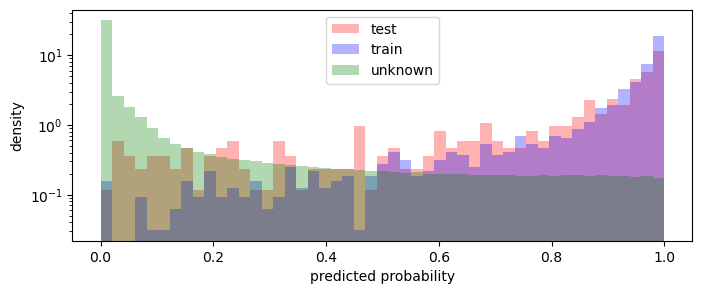

In [10]:
metric = 'prob'

_bins = np.linspace(min(res[metric]), max(res[metric]), 50)

plt.figure(figsize=(8,3))

plt.hist(res[lambda x: x.test_edge][metric], bins=_bins, color='r',alpha=0.3, label='test', density=True) 
plt.hist(res[lambda x: x.train_edge][metric], bins=_bins, color='b',alpha=0.3, label='train', density=True) 
plt.hist(res[lambda x: ~(x.train_edge | x.test_edge) ][metric], bins=_bins, color='g',alpha=0.3, label='unknown', density=True) 

plt.yscale('log')
plt.xlabel(metric)
plt.legend()
plt.xlabel('predicted probability')
plt.ylabel('density')

plt.savefig(f'{root_dir}/OEI_predicted_prob_distributions.png', dpi=300)
plt.show()


In [23]:
perf_dict = eval_edge_inference(res, data=data, metric='prob') 

In [24]:
perf_dict['train']

{'auroc': 0.9611058840866217,
 'aupr': 0.22790044476505192,
 'mrr': 0.3778879843944035,
 'top1_acc': 0.26073232323232326,
 'top10_acc': 0.6565656565656566,
 'top100_acc': 0.9122474747474747,
 'n': 1584}

In [25]:
perf_dict['test']

{'auroc': 0.9112080533968773,
 'aupr': 0.0383194718326052,
 'mrr': 0.20369982148974783,
 'top1_acc': 0.0966183574879227,
 'top10_acc': 0.45410628019323673,
 'top100_acc': 0.855072463768116,
 'n': 414}

In [26]:
perf_dict['test_tft']

{'auroc': 0.8306028982565713,
 'aupr': 0.1016642016583824,
 'mrr': 0.0920003754368974,
 'top1_acc': 0.03338718362950996,
 'top10_acc': 0.21418955304254172,
 'top100_acc': 0.6288368336025848,
 'n': 7428}

In [27]:
perf_dict['test_tft_isolate']

{'auroc': 0.8370984179768414,
 'aupr': 0.036058885614710594,
 'mrr': 0.10765438851131647,
 'top1_acc': 0.036151279199110126,
 'top10_acc': 0.26863181312569523,
 'top100_acc': 0.6885428253615128,
 'n': 1798}

In [28]:
perf_dict['neg']

{'auroc': None,
 'aupr': None,
 'mrr': 0.008366683471337377,
 'top1_acc': 0.0,
 'top10_acc': 0.012175503197418273,
 'top100_acc': 0.133930535171601,
 'n': 722927}